# Gated Recurrent Unit (GRU)

In this section, we forecast EEG activity using a Gated Recurrent Unit (GRU) network. The TCN explored in the previous section captured long-range temporal patterns through an exponentially expanding receptive field built from dilated convolutions, a parallel feedforward process that applies the same fixed computation to every time step. However, biological neural signals like EEG are inherently sequential: the brain state at time $t$ is a function of what came before it. Recurrent neural networks (RNNs) are designed to respect this structure by maintaining a *hidden state*, a compact and dynamically updated representation of past context. The GRU extends this idea with learned gating mechanisms that allow the network to selectively retain relevant history and discard noise, enabling it to model the long-term dependencies essential for capturing the sustained oscillations and slowly-evolving dynamics that characterize EEG.

## Background

Though recurrent architectures were developed decades before convolutional sequence models, they remain a foundational and widely-used approach to time-series modeling due to their natural inductive bias for sequential data. Unlike TCNs and Transformers (which we will cover in the next tutorial), which process an entire input sequence in parallel, RNNs step through the sequence one observation at a time, accumulating a compressed representation of history that informs each subsequent prediction. This makes them conceptually well-aligned with the generative process of EEG, where neural population dynamics evolve as a continuous trajectory through state space. Here we first describe the vanilla RNN to establish the recurrent framework, identify its key limitation, and then show how the GRU resolves it.

### Vanilla Recurrent Neural Network

A vanilla RNN processes an input sequence $\{x_1, x_2, \dots, x_T\}$ one step at a time. At each step $t$, the network reads the current input $x_t \in \mathbb{R}^{n_{in}}$ alongside its own *hidden state* from the previous step $h_{t-1} \in \mathbb{R}^{n_h}$, and produces an updated hidden state:

$$
h_t = \tanh\!\left(W_h\, h_{t-1} + W_x\, x_t + b_h\right) \tag{1}
$$

where $W_h \in \mathbb{R}^{n_h \times n_h}$ is the recurrent weight matrix, $W_x \in \mathbb{R}^{n_h \times n_{in}}$ is the input weight matrix, and $b_h \in \mathbb{R}^{n_h}$ is a bias vector. The hidden state $h_t$ acts as a running summary of the sequence up to time $t$, and is passed forward to the next step as well as to any output layer that generates predictions.

In the context of EEG forecasting, the input $x_t \in \mathbb{R}^m$ is a snapshot of activity across $m$ channels at time $t$. The output at the final step of the input window is projected to generate a forecast over the next $H$ time steps:

$$
\hat{y} = W_{out}\, h_T + b_{out} \tag{2}
$$

where $\hat{y} \in \mathbb{R}^{m \times H}$ is the forecasted sequence. Crucially, the weight matrices $W_h$, $W_x$, and $W_{out}$ are **shared across all time steps**. This weight sharing allows RNNs to generalize across sequences of different lengths and ensures that the model learns temporal relationships rather than position-specific patterns.

### Vanishing Gradients and Long-Term Dependencies

Training a vanilla RNN requires computing gradients of the loss $\mathcal{L}$ with respect to the model's weights. Because the same parameters are applied repeatedly across time steps, this is done via *Backpropagation Through Time* (BPTT), which unrolls the recurrent computation over the full sequence and applies the chain rule. The gradient of the loss with respect to the hidden state at an earlier time step $k < T$ involves a product over every intervening step:

$$
\frac{\partial \mathcal{L}}{\partial h_k} = \frac{\partial \mathcal{L}}{\partial h_T} \prod_{t=k+1}^{T} \frac{\partial h_t}{\partial h_{t-1}} = \frac{\partial \mathcal{L}}{\partial h_T} \prod_{t=k+1}^{T} W_h^\top \odot \operatorname{diag}\!\left(\tanh'(a_t)\right) \tag{3}
$$

where $a_t = W_h h_{t-1} + W_x x_t + b_h$ is the pre-activation at step $t$ and $\tanh'(\cdot) \in [0,\,1]$ is the element-wise derivative of the $\tanh$ nonlinearity.

The problem lies in this **repeated matrix product**. Each factor systematically attenuates the gradient: because $\tanh'(a) \leq 1$, and because the recurrent weight matrix $W_h$ is often smaller than unity in spectral norm after gradient descent, the product $(W_h^\top)^{T-k}$ shrinks exponentially with the temporal distance $T - k$. This is the **vanishing gradient problem**: by the time the gradient signal reaches observations far in the past, it has become negligibly small and the corresponding weights receive no meaningful update. In practice, the model forgets anything beyond a short effective context window. Conversely, if the singular values of $W_h$ exceed 1, the product diverges as an **exploding gradient** that destabilizes training entirely.

For EEG forecasting, where relevant dynamics such as low-frequency oscillations ($\delta$, $\theta$, $\alpha$) or slowly-modulated evoked responses can span hundreds to thousands of time steps, vanishing gradients are a fundamental barrier to learning in a vanilla RNN.

### Gated Recurrent Unit (GRU)

The Gated Recurrent Unit, introduced by Cho et al. (2014), addresses the vanishing gradient problem by replacing the simple recurrent update in Equation (1) with a pair of learned *gates* that adaptively control the flow of information through the hidden state. Rather than forcing all past context through a single saturating nonlinearity, the GRU provides a direct, lightly-attenuated pathway for gradients to flow backward in time.

#### Reset Gate

The **reset gate** $r_t \in (0,\,1)^{n_h}$ determines how much of the previous hidden state $h_{t-1}$ to use when computing the candidate new state:

$$
r_t = \sigma\!\left(W_r\, x_t + U_r\, h_{t-1} + b_r\right) \tag{4}
$$

where $W_r \in \mathbb{R}^{n_h \times n_{in}}$ is the input weight matrix, $U_r \in \mathbb{R}^{n_h \times n_h}$ is the recurrent weight matrix, and $b_r \in \mathbb{R}^{n_h}$ is a bias vector for the reset gate. When $r_t \approx 0$, the gate erases the prior hidden state, allowing the network to start fresh when the current input is unrelated to past context. When $r_t \approx 1$, the full prior state passes through unchanged.

#### Update Gate

The **update gate** $z_t \in (0,\,1)^{n_h}$ controls how much of the hidden state should be updated versus preserved from the previous step:

$$
z_t = \sigma\!\left(W_z\, x_t + U_z\, h_{t-1} + b_z\right) \tag{5}
$$

where $W_z \in \mathbb{R}^{n_h \times n_{in}}$ is the input weight matrix, $U_z \in \mathbb{R}^{n_h \times n_h}$ is the recurrent weight matrix, and $b_z \in \mathbb{R}^{n_h}$ is a bias vector for the update gate.

#### Candidate Hidden State

Given the reset gate, a *candidate* hidden state $\tilde{h}_t$ is computed as in a vanilla RNN but with the previous state masked by $r_t$:

$$
\tilde{h}_t = \tanh\!\left(W_h\, x_t + U_h\, (r_t \odot h_{t-1}) + b_h\right) \tag{6}
$$

where $U_h \in \mathbb{R}^{n_h \times n_h}$ is a recurrent weight matrix distinct from $U_r$: while $U_r$ weighs the previous hidden state when deciding *how much* past context to expose, $U_h$ weighs the (reset-masked) hidden state when computing the *new candidate content*. The element-wise product $r_t \odot h_{t-1}$ selectively zeros out components of past state that are no longer useful, freeing the network to form a new representation informed primarily by the current input.

#### Hidden State Update

The new hidden state is computed as a **linear interpolation** between the previous state and the candidate:

$$
h_t = (1 - z_t) \odot h_{t-1}\; +\; z_t \odot \tilde{h}_t \tag{7}
$$

This interpolation is the key innovation. When $z_t \approx 0$, the hidden state is carried forward nearly unchanged, forming a direct, multiplicatively-unattenuated pathway for gradients to flow back through time via the $(1 - z_t) \odot h_{t-1}$ term. This is analogous to the residual connections used in the TCN, but here the shortcut is dynamically controlled by the data rather than fixed by architecture. When $z_t \approx 1$, the network fully replaces the hidden state with the new candidate, which is useful for rapidly adapting to regime changes in the signal such as a stimulus onset in an EEG epoch. Together, the reset and update gates allow the GRU to selectively preserve long-range context where it matters while remaining flexible enough to track rapid transients, making it well-suited for the rich temporal structure of neural recordings.

## Implementing GRU

Lets see how well the GRU is able to forecast neural activity. We will use PyTorch's built-in `nn.GRU` module to construct the model.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import math
from tqdm import trange
import matplotlib.pyplot as plt

First, lets load the SSVEP dataset from Gu et al., 2024. As in the TCN and Transformer tutorials, we will use every trial within the dataset to train and evaluate the model.

In [2]:
# load single subject from Gu et al., 2024 SSVEP experiment
# Note, data has been downsampled to 250 Hz
data = np.load('../dataset/Data/data_s1_64_down.npy')

In [3]:
# block x stimulation frequency x time x channels x conditions (i.e., modulation depths; low and high luminance ratios)
# stimulation frequencies are from 1-60 in increments of 1 Hz
nBlocks, nFreqs, nTime, nChans, nCons = data.shape

# block x stim freqs x time x channels
con_idx = 1
X = data[:, :, :, :, con_idx]

# collapse over stimulation frequencies to increase amount of data
X = X.reshape(-1, *X.shape[2:])

# transpose to make block x channels x time
X = np.swapaxes(X, 1, 2)

# SSVEPs are typically localized over the P-PO-O electrodes
ssvep_chan_names = ['Pz', 'PO5', 'PO3', 'POz', 'PO4', 'PO6', 'O1', 'Oz', 'O2']
ssvep_chans_idx = [48,54,55,56,57,58,61,62,63]

ssvep_chans_dict = dict(zip(ssvep_chan_names, ssvep_chans_idx))

In [4]:
# construct time vector. Stimulation time is 5s, and epochs included 0.14s post stimulus offset
Fs = 250.
t = np.arange(0, 5.14, 1/Fs) * 1000

Next, we define a custom dataset class compatible with the PyTorch `DataLoader` to facilitate batch sampling during training:

In [5]:
class customDataSet(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        # sample dataset
        X = self.data[idx, :]
        return X

Now, lets define the GRU model. The architecture is deliberately minimal: a stack of GRU layers processes the input sequence step by step, and the final hidden state of the last layer serves as a fixed-size summary of the entire input window. A single linear projection maps this summary to all `pred_len` forecast steps across all channels simultaneously.

In [6]:
class GRUForecaster(nn.Module):
    """
    Stacked GRU for multivariate EEG forecasting.

    Args:
        n_channels:  Number of EEG channels (input and output features).
        hidden_size: Number of features in each GRU hidden state.
        num_layers:  Number of stacked GRU layers.
        pred_len:    Number of future time steps to forecast.
        dropout:     Dropout probability applied between GRU layers (ignored when num_layers=1).
    """

    def __init__(
        self,
        n_channels: int,
        hidden_size: int,
        num_layers: int,
        pred_len: int,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.pred_len: int = pred_len
        self.n_channels: int = n_channels

        # Stack of GRU layers; each layer reads the outputs of the layer below it
        self.gru = nn.GRU(
            input_size=n_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,                              # expects (B, T, C) input
            dropout=dropout if num_layers > 1 else 0.0,   # inter-layer dropout
        )

        # Project the final hidden state to all forecast steps across all channels
        self.output_proj = nn.Linear(hidden_size, pred_len * n_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, T, C) — input EEG window, channels last.
        Returns:
            (B, pred_len, C) — forecasted values.
        """
        # Run the full sequence through the GRU; h_n holds the final hidden state
        _, h_n = self.gru(x)                            # h_n: (num_layers, B, hidden_size)

        # Take the last layer's hidden state as the sequence-level context vector
        h_last: torch.Tensor = h_n[-1]                  # (B, hidden_size)

        # Project to all forecast steps simultaneously and reshape to (B, pred_len, C)
        out: torch.Tensor = self.output_proj(h_last)
        return out.view(x.size(0), self.pred_len, self.n_channels)

As we did in the previous tutorials, lets split the data into training, validation, and test sets, normalize using training statistics, and construct the data loaders:

In [7]:
nTrials = X.shape[0]
nTestTrials = math.ceil(nTrials * 0.2)  # 20% test
shuffIdx = np.random.permutation(nTrials)

X_test = X[shuffIdx[-nTestTrials:], :]
X_train_val = X[shuffIdx[:-nTestTrials], :]

nValidTrials = math.ceil(X_train_val.shape[0] * 0.2)  # 20% validation
X_val = X_train_val[-nValidTrials:, :]
X_train = X[:-nValidTrials, :]

In [8]:
X_train_mu, X_train_sd = X_train.mean(), X_train.std()

# normalize using training set statistics to prevent data leakage
X_train = (X_train - X_train_mu) / X_train_sd
X_val   = (X_val   - X_train_mu) / X_train_sd
X_test  = (X_test  - X_train_mu) / X_train_sd

In [9]:
X_train = torch.Tensor(X_train).to(torch.float32)
X_val   = torch.Tensor(X_val).to(torch.float32)
X_test  = torch.Tensor(X_test).to(torch.float32)

In [10]:
train_dataset = customDataSet(X_train)
val_dataset   = customDataSet(X_val)
test_dataset  = customDataSet(X_test)

In [ ]:
BATCH_SIZE  = 64
LEARN_RATE  = 1e-3
N_EPOCHS    = 150
HORIZON_MS  = 1000
HORIZON     = abs(t - HORIZON_MS).argmin().item() + 1  # forecast last 1000 ms
SEQ_LENGTH  = nTime - HORIZON
UPDATE_FREQ = 50

In [12]:
trainDL = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valDL   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
testDL  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [13]:
device = torch.device('cuda')

In [22]:
model = GRUForecaster(
    n_channels=nChans,   # one input feature per EEG channel
    hidden_size=256,     # dimension of the GRU hidden state
    num_layers=4,        # four stacked GRU layers
    pred_len=HORIZON,    # forecast horizon, equivalent to 1000 ms
    dropout=0.05,
).to(device)

In [23]:
optimizer = optim.NAdam(model.parameters(), lr=LEARN_RATE)
criterion = nn.MSELoss()

The GRU model expects channels-last input of shape `(B, T, C)`, so we transpose the batches (stored as `(B, C, T)`) before passing them through the model, and transpose the predictions back to `(B, C, pred_len)` to match the target:

In [24]:
# Training loop
train_loss: list[float] = []
val_loss: list[float] = []

for iEpoch in trange(N_EPOCHS):
    model.train()
    epoch_train_loss = 0.0

    for train_batch in trainDL:
        # batches are (B, C, T); split chronologically into input and target windows
        input_sequence  = train_batch[:, :, :-HORIZON].to(device)
        target_sequence = train_batch[:, :, -HORIZON:].to(device)

        # GRU expects channels-last (B, T, C); transpose predictions back to (B, C, pred_len)
        batch_predictions = model(input_sequence.transpose(1, 2)).transpose(1, 2)
        batch_loss = criterion(batch_predictions, target_sequence)

        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()

        epoch_train_loss += batch_loss.item()

    train_loss.append(epoch_train_loss / len(trainDL))

    # Validation
    if (iEpoch + 1) % UPDATE_FREQ == 0:
        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for val_batch in valDL:
                input_sequence  = val_batch[:, :, :-HORIZON].to(device)
                target_sequence = val_batch[:, :, -HORIZON:].to(device)

                batch_predictions = model(input_sequence.transpose(1, 2)).transpose(1, 2)
                batch_loss = criterion(batch_predictions, target_sequence)

                epoch_val_loss += batch_loss.item()

            val_loss.append(epoch_val_loss / len(valDL))

        print(f"Epoch [{iEpoch + 1}/{N_EPOCHS}] | Train Loss: {epoch_train_loss/len(trainDL):.3e} | Val Loss: {epoch_val_loss/len(valDL):.3e}")

 17%|█▋        | 25/150 [01:03<05:22,  2.58s/it]

Epoch [25/150] | Train Loss: 5.436e-01 | Val Loss: 6.105e-01


 33%|███▎      | 50/150 [02:06<04:22,  2.62s/it]

Epoch [50/150] | Train Loss: 3.878e-01 | Val Loss: 4.372e-01


 50%|█████     | 75/150 [03:10<03:10,  2.54s/it]

...

Epoch [100/150] | Train Loss: 2.225e-01 | Val Loss: 3.142e-01


 83%|████████▎ | 125/150 [05:22<01:14,  3.00s/it]

Epoch [125/150] | Train Loss: 1.906e-01 | Val Loss: 2.930e-01


100%|██████████| 150/150 [06:34<00:00,  2.63s/it]

Epoch [150/150] | Train Loss: 1.718e-01 | Val Loss: 2.841e-01


Lets take a look at the training results and how well the model performs on the test data set:

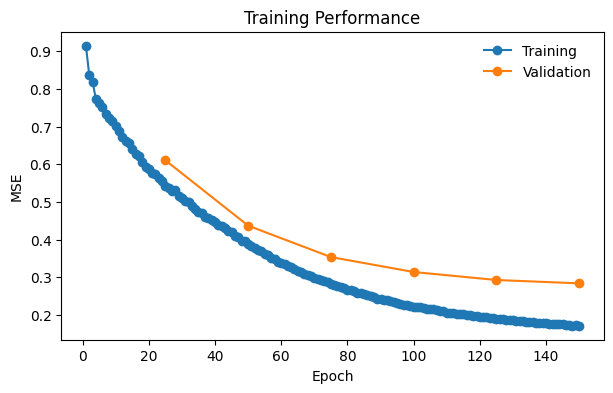

In [29]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(N_EPOCHS) + 1, train_loss, marker='o', label='Training')
plt.plot(
    [x for x in np.arange(N_EPOCHS) + 1 if not x % UPDATE_FREQ],
    val_loss,
    marker='o',
    label='Validation'
)
plt.title('Training Performance')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend(frameon=False)
plt.show()

In [30]:
model.eval()
with torch.no_grad():
    input_sequence  = X_test[:, :, :-HORIZON].to(device)
    target_sequence = X_test[:, :, -HORIZON:].to(device)

    predictions = model(input_sequence.transpose(1, 2)).transpose(1, 2)

    # denormalize predictions and targets back to original scale (µV)
    target_denorm = ((target_sequence * X_train_sd) + X_train_mu).cpu().numpy()
    predictions   = ((predictions    * X_train_sd) + X_train_mu).cpu().numpy()

    residuals = target_denorm - predictions
    test_rmse = np.sqrt((residuals**2).mean())

print(f'Test RMSE: {test_rmse:0.3e}')

Test RMSE: 6.244e+00


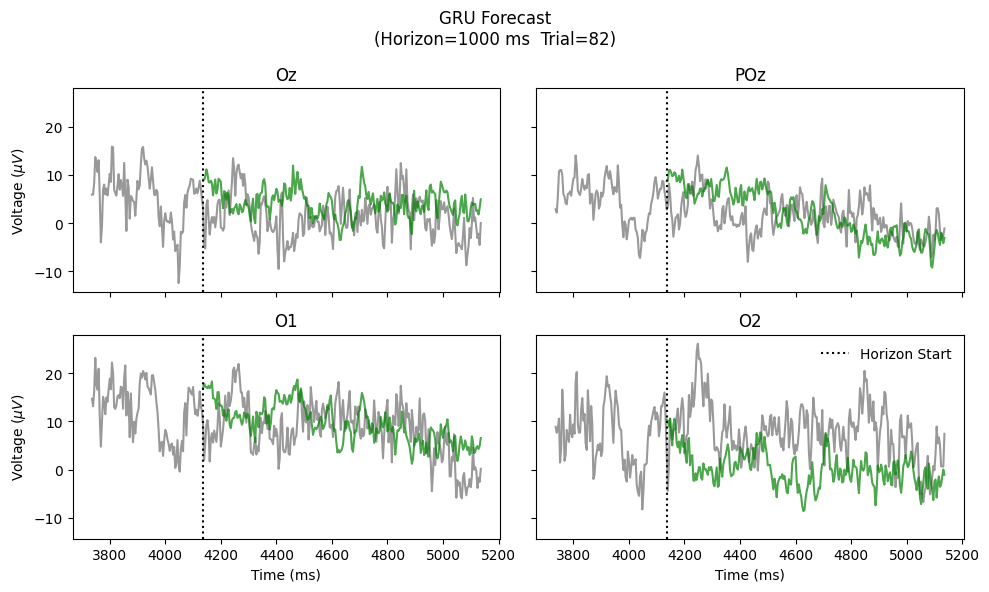

In [31]:
# Plot single trial performance
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), dpi=100, sharex=True, sharey=True)
trial_idx = 81
time_plot_buffer = 100  # show 100 samples before the horizon for context
axs = axs.ravel()

X_test_denorm = ((X_test * X_train_sd) + X_train_mu).cpu().numpy()

for i, c in enumerate(['Oz', 'POz', 'O1', 'O2']):
    axs[i].plot(t[-(HORIZON + time_plot_buffer):],
                X_test_denorm[trial_idx, ssvep_chans_dict[c], -(HORIZON + time_plot_buffer):],
                color='k', alpha=0.4)
    axs[i].plot(t[-HORIZON:], predictions[trial_idx, ssvep_chans_dict[c], :], color='g', alpha=0.7)
    axs[i].axvline(t[-HORIZON], color='black', linestyle=':', label='Horizon Start')
    axs[i].set_title(c)

    if i > 1:
        axs[i].set_xlabel('Time (ms)')
    if i in [0, 2]:
        axs[i].set_ylabel(r'Voltage ($\mu V$)')
    if i == 3:
        axs[i].legend(frameon=False)

plt.suptitle(f'GRU Forecast\n(Horizon={HORIZON_MS} ms  Trial={trial_idx + 1})')
plt.tight_layout()
plt.show()

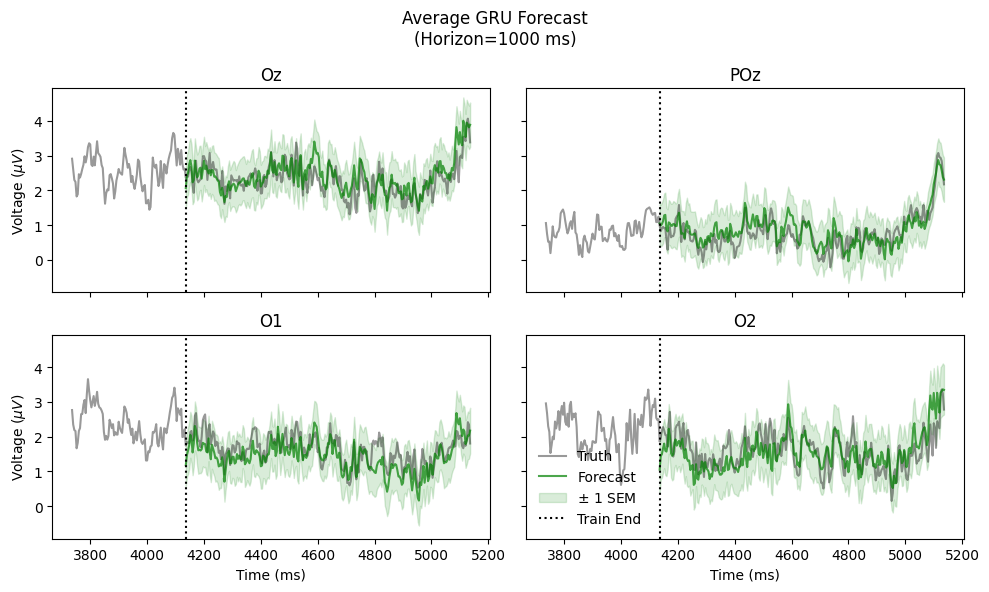

In [32]:
# Plot forecasting performance averaged across trials
average_preds = predictions.mean(axis=0)
average_truth = X_test_denorm.mean(axis=0)
preds_sem     = predictions.std(axis=0) / np.sqrt(predictions.shape[0])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), dpi=100, sharex=True, sharey=True)
time_plot_buffer = 100
axs = axs.ravel()

for i, c in enumerate(['Oz', 'POz', 'O1', 'O2']):
    axs[i].plot(t[-(HORIZON + time_plot_buffer):],
                average_truth[ssvep_chans_dict[c], -(HORIZON + time_plot_buffer):],
                color='k', alpha=0.4, label='Truth')
    axs[i].plot(t[-HORIZON:], average_preds[ssvep_chans_dict[c], :], color='g', alpha=0.7, label='Forecast')
    axs[i].fill_between(
        t[-HORIZON:],
        average_preds[ssvep_chans_dict[c], :] - preds_sem[ssvep_chans_dict[c], :],
        average_preds[ssvep_chans_dict[c], :] + preds_sem[ssvep_chans_dict[c], :],
        color='g', alpha=0.15, label=r'$\pm \ 1 \text{ SEM}$'
    )
    axs[i].axvline(t[-HORIZON], color='black', linestyle=':', label='Train End')
    axs[i].set_title(c)

    if i > 1:
        axs[i].set_xlabel('Time (ms)')
    if i in [0, 2]:
        axs[i].set_ylabel(r'Voltage ($\mu V$)')
    if i == 3:
        axs[i].legend(frameon=False)

plt.suptitle(f'Average GRU Forecast\n(Horizon={HORIZON_MS} ms)')
plt.tight_layout()
plt.show()

At the single-trial level, the GRU captures the broad temporal structure of the SSVEP response, tracking the general amplitude envelope and low-frequency trends across posterior channels. As with the TCN, the model fails to accurately predict sharp transients voltage deflections, which is likely a consequence of the entire input window being compressed into a single fixed-size hidden state. The trial-averaged forecasts show closer correspondence with the ground-truth ERP, consistent with the model having reliably learned the mean temporal trajectory of the response.

# Summary

The GRU offers a principled solution to the vanishing gradient problem inherent in vanilla RNNs, enabling the model to maintain a dynamic hidden state that selectively retains or discards temporal context over long sequences via learned reset and update gates. By processing EEG activity step by step, the architecture naturally respects the causal structure of neural recordings and accumulates a compact representation of the entire input window into a single context vector.